# SOH Full vs Partial Flight Anchor Check

This notebook is a simple sanity check for a useful modeling idea:

- treat **deeper full-range flights** as higher-quality SOH anchor points
- treat **partial flights** as noisier observations
- check whether raw SOH spikes are more common on deeper flights than on partial flights

The goal is not to build the final label here. The goal is to quickly test whether the full-vs-partial flight interpretation is supported by the data.

## Why this matters

A BMS SOH estimator may become more informative on flights that span a larger SOC range because those events expose more of the pack behavior.

That means a flight starting near full and discharging through a larger SOC span may behave differently from a shallow mid-band flight. If so, the raw SOH can move in ways that depend on the operating window rather than true health alone.

If the notebook supports that pattern, then a good label-building strategy is:

1. Keep deeper full-range flight SOH points as higher-trust anchors.
2. Downweight or ignore partial-flight SOH as direct labels.
3. Fit a smooth degradation curve through the anchors.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.isotonic import IsotonicRegression


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'ml_workspace').exists() and (candidate / 'data').exists():
            return candidate
    raise RuntimeError('Could not locate project root from notebook working directory.')


def resolve_timeseries_path(project_root: Path) -> Path:
    preferred = project_root / 'data' / 'event_timeseries_corrected.parquet'
    fallback = project_root / 'data' / 'event_timeseries.parquet'
    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    raise FileNotFoundError('Could not find event_timeseries_corrected.parquet or event_timeseries.parquet under data/.')


PROJECT_ROOT = find_project_root(Path.cwd())
TIMESERIES_PATH = resolve_timeseries_path(PROJECT_ROOT)

PLANE_FOCUS = '166'
SPIKE_THRESHOLD_PCT = 2.0
ANCHOR_START_SOC_PCT = 95.0
ANCHOR_SOC_DELTA_PCT = 20.0
ANCHOR_MIN_SOC_PCT = 30.0
EDGE_SAMPLES = 25

plt.style.use('default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

TIMESERIES_PATH

PosixPath('/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/data/event_timeseries_corrected.parquet')

## Build a flight-event table

For each battery and flight event, compute:

- `observed_soh_pct`
- `delta_soh_pct`
- `soc_start_pct`
- `soc_end_pct`
- `soc_min_pct`
- `soc_max_pct`
- `soc_delta_pct = soc_start_pct - soc_end_pct`
- `anchor_basic = soc_start_pct >= 95% and soc_delta_pct >= 20%`
- `anchor_strict = anchor_basic and soc_min_pct <= 30%`

In [2]:
def classify_event_type(frame: pd.DataFrame) -> str:
    is_charge = int(frame['is_charging_event'].max())
    is_flight = int(frame['is_flight_event'].max())
    if is_charge and not is_flight:
        return 'charge'
    if is_flight and not is_charge:
        return 'flight'
    if is_charge and is_flight:
        return 'mixed'
    return 'other'


def build_flight_event_table(timeseries_path: Path) -> pd.DataFrame:
    cols = [
        'plane_id', 'flight_id', 'event_datetime', 'source_csv_kind', 'source_pack_id',
        'is_charging_event', 'is_flight_event', 'time_ms',
        ' bat 1 soh', ' bat 2 soh', ' bat 1 soc', ' bat 2 soc',
        ' bat 1 current', ' bat 2 current',
    ]
    raw = pd.read_parquet(timeseries_path, columns=cols)
    raw = raw[raw['source_csv_kind'].eq('aux') & raw['source_pack_id'].isin([1, 2])].copy()
    raw['event_datetime'] = pd.to_datetime(raw['event_datetime'])
    raw = raw.dropna(subset=['event_datetime'])

    rows = []
    for battery_id in [1, 2]:
        df = raw[raw['source_pack_id'].eq(battery_id)].copy()
        soh_col = f' bat {battery_id} soh'
        soc_col = f' bat {battery_id} soc'
        current_col = f' bat {battery_id} current'
        for col in [soh_col, soc_col, current_col]:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df = df.sort_values(['plane_id', 'event_datetime', 'flight_id', 'time_ms'])

        for (plane_id, flight_id, event_datetime), group in df.groupby(['plane_id', 'flight_id', 'event_datetime'], sort=False):
            event_type = classify_event_type(group)
            if event_type != 'flight':
                continue

            soc = group[soc_col].dropna().to_numpy()
            soh = group[soh_col].dropna().to_numpy()
            current = group[current_col].dropna().to_numpy()

            soc_start = soc_end = soc_min = soc_max = soc_delta = np.nan
            if soc.size:
                k = min(EDGE_SAMPLES, soc.size)
                soc_start = float(np.nanmedian(soc[:k]))
                soc_end = float(np.nanmedian(soc[-k:]))
                soc_min = float(np.nanmin(soc))
                soc_max = float(np.nanmax(soc))
                soc_delta = float(soc_start - soc_end)

            rows.append({
                'plane_id': str(plane_id),
                'battery_id': battery_id,
                'flight_id': int(flight_id),
                'event_datetime': event_datetime,
                'observed_soh_pct': float(np.nanmedian(soh)) if soh.size else np.nan,
                'soc_start_pct': soc_start,
                'soc_end_pct': soc_end,
                'soc_min_pct': soc_min,
                'soc_max_pct': soc_max,
                'soc_delta_pct': soc_delta,
            })

    events = pd.DataFrame(rows)
    events = events.sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)

    out = []
    for (plane_id, battery_id), group in events.groupby(['plane_id', 'battery_id'], sort=False):
        group = group.sort_values(['event_datetime', 'flight_id']).copy()
        group['event_index'] = np.arange(len(group))
        group['delta_soh_pct'] = group['observed_soh_pct'].diff()
        group['spike_up'] = group['delta_soh_pct'] >= SPIKE_THRESHOLD_PCT
        group['anchor_basic'] = (group['soc_start_pct'] >= ANCHOR_START_SOC_PCT) & (group['soc_delta_pct'] >= ANCHOR_SOC_DELTA_PCT)
        group['anchor_strict'] = group['anchor_basic'] & (group['soc_min_pct'] <= ANCHOR_MIN_SOC_PCT)
        out.append(group)

    return pd.concat(out, ignore_index=True)


flight_df = build_flight_event_table(TIMESERIES_PATH)
focus = flight_df[flight_df['plane_id'].eq(PLANE_FOCUS)].copy()
display(focus.head())

,plane_id,battery_id,flight_id,event_datetime,observed_soh_pct,soc_start_pct,soc_end_pct,soc_min_pct,soc_max_pct,soc_delta_pct,event_index,delta_soh_pct,spike_up,anchor_basic,anchor_strict
0,166,1,4620,2023-06-03 10:11:00,97.0,100.0,33.0,0.0,100.0,67.0,0,NaN,False,True,True
1,166,1,4622,2023-06-04 10:25:00,97.0,100.0,34.0,34.0,100.0,66.0,1,0.0,False,True,False
2,166,1,4633,2023-06-09 14:37:00,97.0,100.0,73.0,73.0,100.0,27.0,2,0.0,False,True,False
3,166,1,4636,2023-06-11 10:12:00,97.0,100.0,29.0,29.0,100.0,71.0,3,0.0,False,True,True
4,166,1,4669,2023-06-21 10:38:00,97.0,100.0,38.0,38.0,100.0,62.0,4,0.0,False,True,False


## Basic counts

This first table checks whether there are enough anchor candidates to matter.

In [3]:
count_summary = (
    focus.groupby('battery_id')
    .apply(lambda g: pd.Series({
        'flight_events': len(g),
        'basic_anchor_events': int(g['anchor_basic'].sum()),
        'strict_anchor_events': int(g['anchor_strict'].sum()),
        'partial_events': int((~g['anchor_basic']).sum()),
        'median_soc_delta_anchor_pct': g.loc[g['anchor_basic'], 'soc_delta_pct'].median(),
        'median_soc_delta_partial_pct': g.loc[~g['anchor_basic'], 'soc_delta_pct'].median(),
    }))
    .reset_index()
)
display(count_summary.round(3))

/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_2606/2705303361.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,battery_id,flight_events,basic_anchor_events,strict_anchor_events,partial_events,median_soc_delta_anchor_pct,median_soc_delta_partial_pct
0,1,188.0,179.0,68.0,9.0,55.0,17.0
1,2,188.0,179.0,73.0,9.0,54.0,16.0


## Full vs partial spike rates

This is the key test: do deeper full-range flight anchors spike more often than partial-flight events?

/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_2606/4237015811.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,battery_id,basic_anchor_spike_rate,strict_anchor_spike_rate,partial_spike_rate,basic_anchor_spikes,strict_anchor_spikes,partial_spikes
0,1,0.089,0.118,0.0,16.0,8.0,0.0
1,2,0.106,0.123,0.0,19.0,9.0,0.0


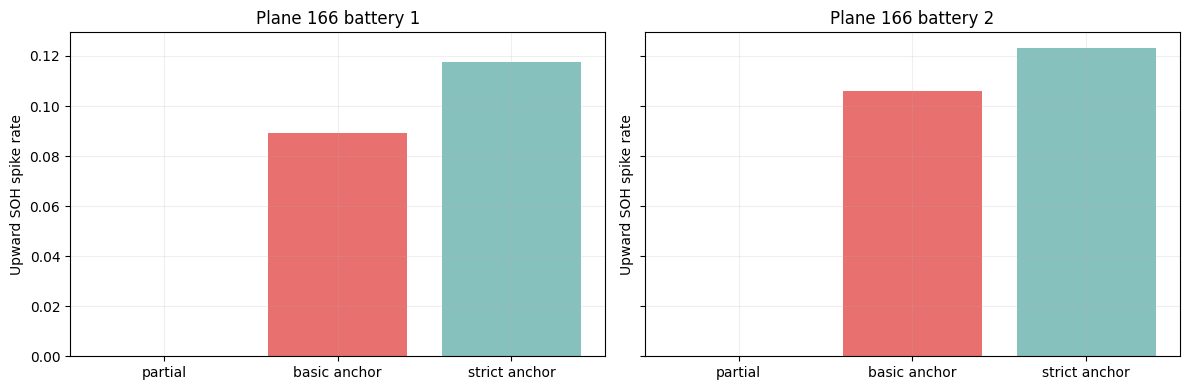

In [4]:
spike_summary = (
    focus.groupby('battery_id')
    .apply(lambda g: pd.Series({
        'basic_anchor_spike_rate': g.loc[g['anchor_basic'], 'spike_up'].mean(),
        'strict_anchor_spike_rate': g.loc[g['anchor_strict'], 'spike_up'].mean(),
        'partial_spike_rate': g.loc[~g['anchor_basic'], 'spike_up'].mean(),
        'basic_anchor_spikes': int(g.loc[g['anchor_basic'], 'spike_up'].sum()),
        'strict_anchor_spikes': int(g.loc[g['anchor_strict'], 'spike_up'].sum()),
        'partial_spikes': int(g.loc[~g['anchor_basic'], 'spike_up'].sum()),
    }))
    .reset_index()
)
display(spike_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, battery_id in enumerate([1, 2]):
    row = spike_summary[spike_summary['battery_id'].eq(battery_id)].iloc[0]
    axes[i].bar(
        ['partial', 'basic anchor', 'strict anchor'],
        [row['partial_spike_rate'], row['basic_anchor_spike_rate'], row['strict_anchor_spike_rate']],
        color=['#4c78a8', '#e45756', '#72b7b2'],
        alpha=0.85,
    )
    axes[i].set_title(f'Plane {PLANE_FOCUS} battery {battery_id}')
    axes[i].set_ylabel('Upward SOH spike rate')
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Raw SOH over time: full-range vs partial flights

If anchor events really behave differently, they should stand out on the raw SOH timeline.

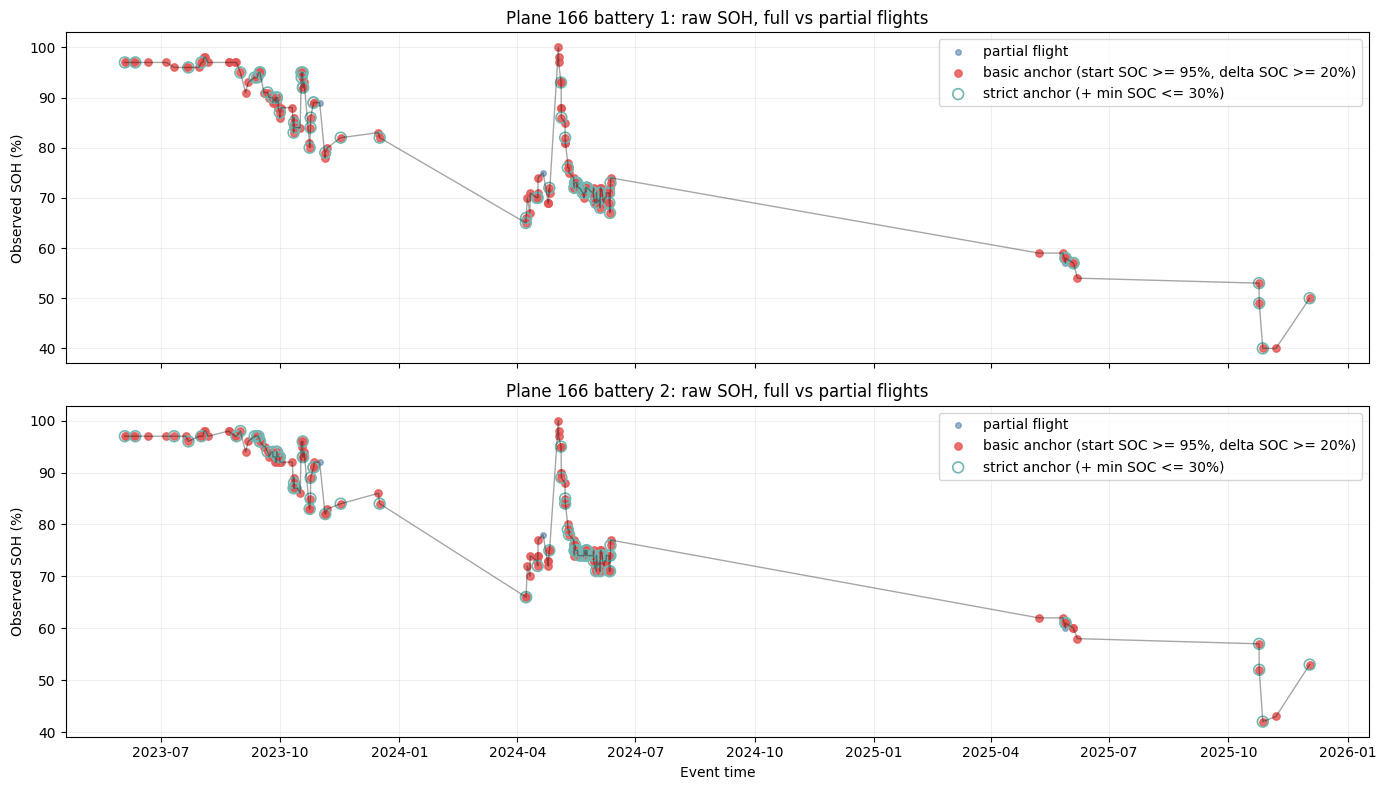

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for i, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    axes[i].plot(g['event_datetime'], g['observed_soh_pct'], color='black', linewidth=1.0, alpha=0.35)
    axes[i].scatter(g.loc[~g['anchor_basic'], 'event_datetime'], g.loc[~g['anchor_basic'], 'observed_soh_pct'], s=16, alpha=0.55, color='#4c78a8', label='partial flight')
    axes[i].scatter(g.loc[g['anchor_basic'], 'event_datetime'], g.loc[g['anchor_basic'], 'observed_soh_pct'], s=28, alpha=0.85, color='#e45756', label='basic anchor (start SOC >= 95%, delta SOC >= 20%)')
    axes[i].scatter(g.loc[g['anchor_strict'], 'event_datetime'], g.loc[g['anchor_strict'], 'observed_soh_pct'], s=60, facecolors='none', edgecolors='#72b7b2', linewidth=1.2, label='strict anchor (+ min SOC <= 30%)')
    axes[i].set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: raw SOH, full vs partial flights')
    axes[i].set_ylabel('Observed SOH (%)')
    axes[i].grid(alpha=0.2)
    axes[i].legend(loc='best')

axes[-1].set_xlabel('Event time')
plt.tight_layout()
plt.show()

## Monotone anchor curve

This is not the final target pipeline, just a quick proof of concept.

We fit an isotonic regression through the **basic anchor** flight points only, then compare it to the raw flight-event SOH.

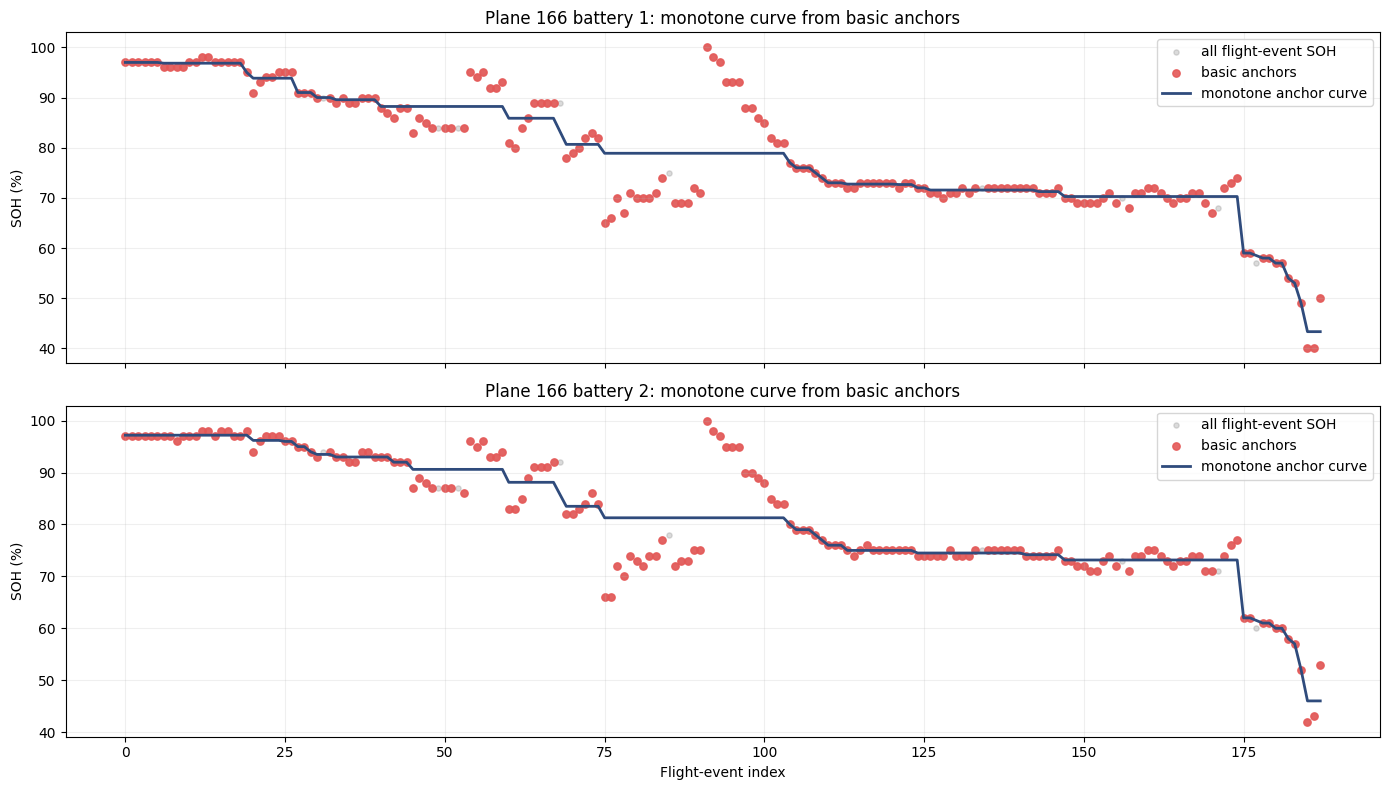

,battery_id,n_basic_anchors,anchor_first_soh,anchor_last_soh,anchor_curve_drop_pct
0,1,179,97.0,50.0,53.667
1,2,179,97.0,53.0,51.200


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
anchor_curve_summary = []

for i, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    anchors = g[g['anchor_basic'] & g['observed_soh_pct'].notna()].copy()

    axes[i].scatter(g['event_index'], g['observed_soh_pct'], s=14, alpha=0.35, color='#999999', label='all flight-event SOH')
    axes[i].scatter(anchors['event_index'], anchors['observed_soh_pct'], s=28, alpha=0.9, color='#e45756', label='basic anchors')

    if len(anchors) >= 2:
        iso = IsotonicRegression(increasing=False, out_of_bounds='clip')
        y_fit = iso.fit_transform(anchors['event_index'], anchors['observed_soh_pct'])
        anchor_curve = pd.Series(y_fit, index=anchors['event_index'])
        interp_curve = np.interp(g['event_index'], anchor_curve.index.to_numpy(), anchor_curve.to_numpy())
        axes[i].plot(g['event_index'], interp_curve, color='#2f4b7c', linewidth=2.0, label='monotone anchor curve')

        anchor_curve_summary.append({
            'battery_id': battery_id,
            'n_basic_anchors': len(anchors),
            'anchor_first_soh': anchors['observed_soh_pct'].iloc[0],
            'anchor_last_soh': anchors['observed_soh_pct'].iloc[-1],
            'anchor_curve_drop_pct': float(interp_curve[0] - interp_curve[-1]),
        })

    axes[i].set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: monotone curve from basic anchors')
    axes[i].set_ylabel('SOH (%)')
    axes[i].grid(alpha=0.2)
    axes[i].legend(loc='best')

axes[-1].set_xlabel('Flight-event index')
plt.tight_layout()
plt.show()

display(pd.DataFrame(anchor_curve_summary).round(3))

## Key findings

- The data supports the idea that **deeper full-range flights behave differently from partial flights**.
- For plane `166`, basic anchor flights are defined by `start SOC >= 95%` and `delta SOC >= 20%`.
- Adding a low-min-SOC condition changes very little, which is useful because it means the simpler deep-flight rule already captures most of the effect.
- That pattern is consistent with the estimator behaving differently across flight operating ranges, not true health improving during the event.
- This makes a practical modeling recipe plausible:
  1. Trust deeper full-range flight points more.
  2. Downweight partial-flight raw SOH labels.
  3. Build a smooth degradation target through the anchors.

In [7]:
for battery_id in [1, 2]:
    g = focus[focus['battery_id'].eq(battery_id)].copy()
    basic = g[g['anchor_basic']]
    strict = g[g['anchor_strict']]
    partial = g[~g['anchor_basic']]
    print(f'Plane {PLANE_FOCUS} battery {battery_id}')
    print(f"  flight events: {len(g)}")
    print(f"  basic anchors (start SOC >= {ANCHOR_START_SOC_PCT:.0f}%, delta SOC >= {ANCHOR_SOC_DELTA_PCT:.0f}%): {len(basic)}")
    print(f"  strict anchors (+ min SOC <= {ANCHOR_MIN_SOC_PCT:.0f}%): {len(strict)}")
    print(f"  partial flight events: {len(partial)}")
    print(f"  basic anchor spike rate: {basic['spike_up'].mean():.3f}")
    print(f"  strict anchor spike rate: {strict['spike_up'].mean():.3f}")
    print(f"  partial-flight spike rate: {partial['spike_up'].mean():.3f}")
    print()


Plane 166 battery 1
  flight events: 188
  basic anchors (start SOC >= 95%, delta SOC >= 20%): 179
  strict anchors (+ min SOC <= 30%): 68
  partial flight events: 9
  basic anchor spike rate: 0.089
  strict anchor spike rate: 0.118
  partial-flight spike rate: 0.000

Plane 166 battery 2
  flight events: 188
  basic anchors (start SOC >= 95%, delta SOC >= 20%): 179
  strict anchors (+ min SOC <= 30%): 73
  partial flight events: 9
  basic anchor spike rate: 0.106
  strict anchor spike rate: 0.123
  partial-flight spike rate: 0.000

